# Financial Analytics - Scorecards

In [96]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from optbinning.scorecard import plot_auc_roc, plot_ks
from optbinning import OptimalBinning, BinningProcess, Scorecard
import matplotlib.pyplot as plt

## Load Data

In [ ]:
ac = pd.read_csv("data/accepted_customers.csv")
rc = pd.read_csv("data/rejected_customers.csv")

In [98]:
# Verify Weights

print(pd.crosstab(ac['GB'], ac['_freq_']))
 # weight of 30 for good, 1 for bad

# Sample Info
bad_rate = 0.0323
total_good = 1500
total_bad = 1500

weight = ((total_bad / bad_rate) - total_bad) / total_good

print(weight)
    #optimal weight is ~30

_freq_    1     30
GB                
0          0  1500
1       1500     0
29.959752321981423


In [99]:
# Initial Train/Test/Split
train, test = train_test_split(ac, test_size=0.3, random_state=1234)  #70/30 split

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head(5)

Train shape: (2100, 24)
Test shape : (900, 24)


,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_
1970,3,5,40,66,54,2,2,1,3000,0,...,1,800,Leisure,Lease,German,Others,Car,no credit cards,1,1
2324,0,1,24,312,30,2,0,1,2200,0,...,1,1300,Radio or TV or Hifi,Lease,German,Military Service,Car,no credit cards,1,1
1885,1,2,22,3,60,2,0,0,2000,0,...,1,1800,Radio or TV or Hifi,Lease,German,Others,Car,no credit cards,1,1
2371,0,1,36,144,27,2,0,0,0,1,...,0,500,Dept. Store or Mail,Lease,German,Others,Without Vehicle,Cheque card,1,1
1023,0,1,42,60,30,2,2,1,1600,0,...,0,2500,Furniture or Carpet,Lease,German,Others,Without Vehicle,no credit cards,0,30


## Variable Binning & Selection

#### Weights of Evidence Bins

In [100]:
#Train Data Bins

# Target must be binary (0/1). If "bad" is boolean, convert to int.
if train["GB"].dtype == "bool":
    train["GB"] = train["GB"].astype(int)
    test["GB"] = test["GB"].astype(int)

#define variables
colnames = list(train.columns[0:22])   # every variable except target and weight
X_train = train[colnames]
y_train = train["GB"]

#IV selection criteria
selection_criteria = {"iv": {"min": 0.1, "max": 1}}

#list categorical vars
categorical_vars = ["BUREAU", "CAR", "CARDS", "NAT", "PRODUCT", "PROF", "REGN", "TEL"]

# Safety: keep only categorical vars that actually exist in the dataset
categorical_vars = [c for c in categorical_vars if c in X_train.columns]

In [101]:
#Binning Process - Train

bin_proc = BinningProcess(
    variable_names=colnames,
    selection_criteria=selection_criteria,
    categorical_variables=categorical_vars
)

summary = bin_proc.fit(X_train, y_train).summary()
summary.sort_values("iv", ascending=False).head(22)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
2,AGE,numerical,OPTIMAL,True,8,0.389083,0.047006,0.341598,0.111394
8,INCOME,numerical,OPTIMAL,True,8,0.268925,0.032929,0.287504,0.133748
21,CARDS,categorical,OPTIMAL,True,2,0.189327,0.023299,0.193474,0.382846
4,TMJOB1,numerical,OPTIMAL,True,8,0.17702,0.021569,0.220274,0.053874
1,PERS_H,numerical,OPTIMAL,True,4,0.176798,0.021889,0.214955,0.253062
9,EC_CARD,numerical,OPTIMAL,True,2,0.157998,0.019456,0.171809,0.312224
5,TEL,categorical,OPTIMAL,False,2,0.057385,0.007107,0.09124,0.093116
0,CHILDREN,numerical,OPTIMAL,False,4,0.047069,0.00587,0.111133,0.008188
19,PROF,categorical,OPTIMAL,False,4,0.045712,0.005667,0.092525,0.027403
3,TMADD,numerical,OPTIMAL,False,4,0.040261,0.005009,0.098356,0.094559


#### Fit Scorecard

In [102]:
estimator = LogisticRegression(solver="lbfgs", max_iter=2000)

scorecard = Scorecard(
    binning_process=bin_proc,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,                  #points double every 50 points
        "scorecard_points": 500,    #500 baseline to anchor odds
        "odds": 20                  #at baseline, 20:1 odds
    }
)

scorecard.fit(X_train, y_train, sample_weight=train["_freq_"])

Scorecard(binning_process=BinningProcess(categorical_variables=['BUREAU', 'CAR',
                                                                'CARDS', 'NAT',
                                                                'PRODUCT',
                                                                'PROF', 'REGN',
                                                                'TEL'],
                                         selection_criteria={'iv': {'max': 1,
                                                                    'min': 0.1}},
                                         variable_names=['CHILDREN', 'PERS_H',
                                                         'AGE', 'TMADD',
                                                         'TMJOB1', 'TEL',
                                                         'NMBLOAN', 'FINLOAN',
                                                         'INCOME', 'EC_CARD',
                                                         'BUREAU', 'LOCATION',
                                                         'LOANS', 'REGN', 'DIV',
                                                         'CASH', 'PRODUCT',
                                                         'RESID', 'NAT', 'PROF',
                                                         'CAR', 'CARDS']),
          estimator=LogisticRegression(max_iter=2000),
          scaling_method='pdo_odds',
          scaling_method_params={'odds': 20, 'pdo': 50,
                                 'scorecard_points': 500})

In [103]:
scorecard.table(style="summary")

,Variable,Bin,Points
0,PERS_H,"(-inf, 1.50)",71.393792
1,PERS_H,"[1.50, 2.50)",100.837272
2,PERS_H,"[2.50, 4.50)",97.981014
3,PERS_H,"[4.50, inf)",89.865244
4,PERS_H,Special,88.281890
5,PERS_H,Missing,88.281890
0,AGE,"(-inf, 22.50)",29.980689
1,AGE,"[22.50, 27.50)",58.219621
2,AGE,"[27.50, 30.50)",84.419248
3,AGE,"[30.50, 34.50)",93.136815


#### Model Evaluation

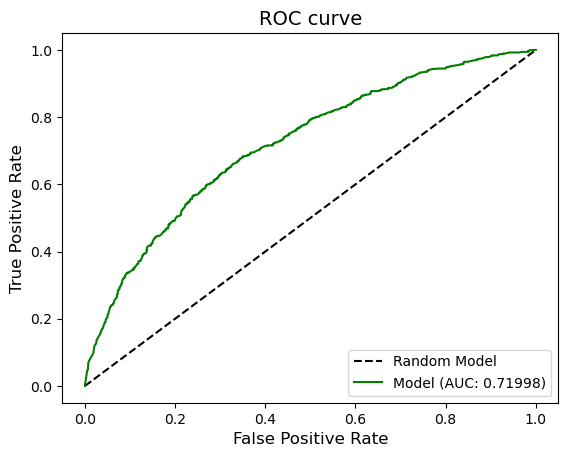

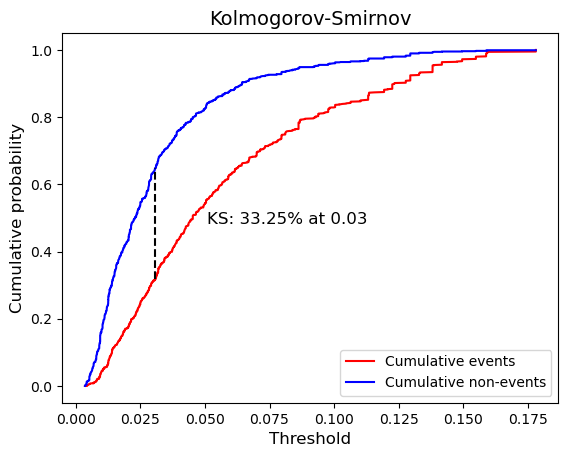

In [104]:
#Training Data
y_pred_train = scorecard.predict_proba(X_train)[:, 1]

plot_auc_roc(y_train, y_pred_train)
plt.show()

plot_ks(y_train, y_pred_train)
plt.show()

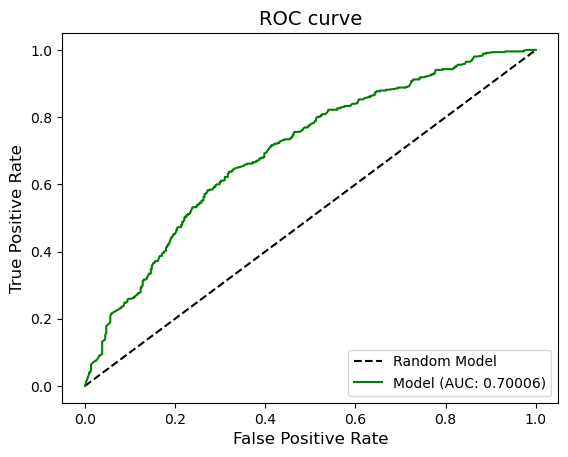

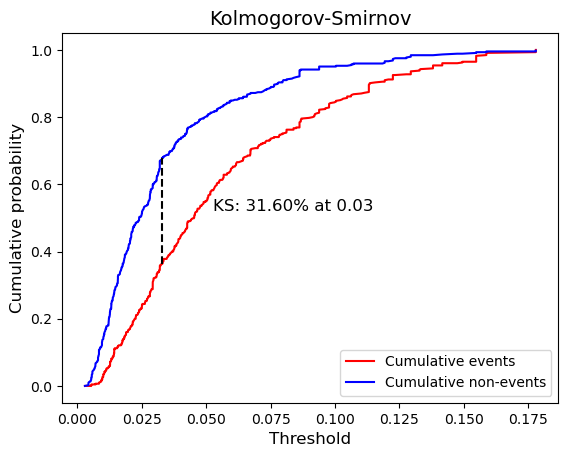

In [105]:
#Test Data
X_test = test[colnames]
y_test = test["GB"]

y_pred_test = scorecard.predict_proba(X_test)[:, 1]

plot_auc_roc(y_test, y_pred_test)
plt.show()

plot_ks(y_test, y_pred_test)
plt.show()

#### Score Test Set

In [ ]:
from sklearn.model_selection import train_test_split

# Recreate canonical split (robust to running this chunk standalone)
ac = pd.read_csv("data/accepted_customers.csv")
train_tmp, test_tmp = train_test_split(ac, test_size=0.3, random_state=1234)

test_final = test_tmp.copy()

# Ensure weight exists
if "_freq_" not in test_final.columns:
    test_final["_freq_"] = 1.0

# Score using the fitted optbinning scorecard and the predictor list `colnames`
test_final["score"] = scorecard.score(test_final[colnames])

test_final[["score", "GB"]].head()

,score,GB
1936,509.838354,1
85,657.997583,0
2045,566.094424,1
1230,541.322491,0
2676,536.520265,1


#### Probability of Default by Decile

In [107]:
# Probability of Default by Decile

good_weight = 30

test_final["decile"] = pd.qcut(test_final["score"], 10, labels=False)

# Counts good/bad by decile
bad_ct = test_final.loc[test_final["GB"] == 1].groupby("decile").size()
good_ct = test_final.loc[test_final["GB"] == 0].groupby("decile").size()

# Align indices in deciles
all_dec = pd.Index(range(10), name="decile")
bad_ct = bad_ct.reindex(all_dec, fill_value=0)
good_ct = good_ct.reindex(all_dec, fill_value=0)

#probability of default for each decile
PD = bad_ct / (good_ct * good_weight + bad_ct)
PD

decile
0    0.101284
1    0.052632
2    0.072165
3    0.056974
4    0.037199
5    0.026243
6    0.026217
7    0.014009
8    0.018370
9    0.008841
dtype: float64

#### Plots of PD score

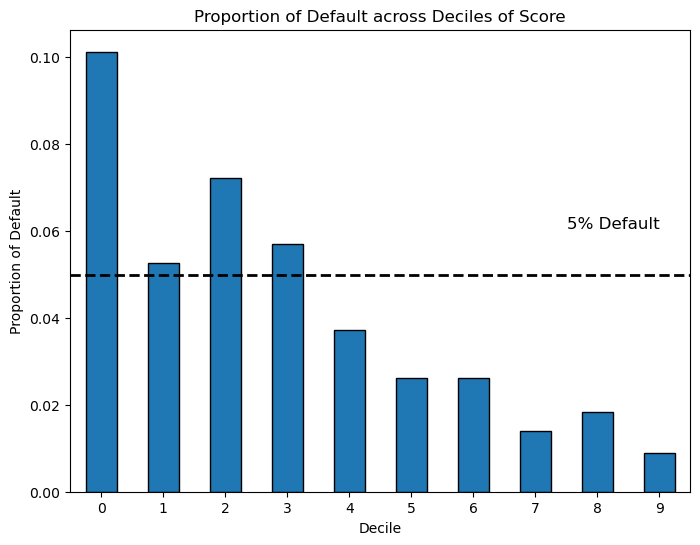

In [108]:

plt.figure(figsize=(8, 6))
PD.plot(kind="bar", edgecolor="black")
plt.axhline(y=0.05, color="black", linestyle="--", linewidth=2)
plt.text(x=9, y=0.06, s="5% Default", color="black", ha="right", va="bottom", fontsize=12)

plt.title("Proportion of Default across Deciles of Score")
plt.xlabel("Decile")
plt.ylabel("Proportion of Default")
plt.xticks(rotation=0)
plt.show()

## Reject Inference

In [109]:
# Calculate Weights when Rejects Added

# Known values
accepted_rate = 75
rejected_rate= 25
bad_rate = 0.0323
good_rate = 0.9678
true_good = 1500
true_bad = 1500
rejects = 1500
sample_prop = 33.33

#Expected Full Pop Percentages
bad_pop_pct = bad_rate*accepted_rate
good_pop_pct = good_rate*accepted_rate
reject_pop_pct = 25

#check values
print(bad_pop_pct)
print(good_pop_pct)

#Weight pop prop/sample prop
bad_base_weight = bad_pop_pct / sample_prop
print(bad_base_weight)
good_base_weight = good_pop_pct / sample_prop
print(good_base_weight)
reject_base_weight = reject_pop_pct / sample_prop
print(reject_base_weight)

#Set bad weight to 1 - adjust other weights
weight_mult = 1/bad_base_weight
final_bad_weight = weight_mult*bad_base_weight
final_good_weight = weight_mult*good_base_weight
final_reject_weight = weight_mult*reject_base_weight

#Final weights
print('Final Bad Weight:', final_bad_weight)
print('Final Good Weight:',final_good_weight)
print('Final Reject Weight:',final_reject_weight)


#assign new good weight before joining with rejects
ac.loc[ac['GB']==0, '_freq_'] = final_good_weight

2.4225000000000003
72.585
0.0726822682268227
2.1777677767776775
0.7500750075007501
Final Bad Weight: 1.0
Final Good Weight: 29.96284829721361
Final Reject Weight: 10.319917440660472


C:\Users\steve\AppData\Local\Temp\ipykernel_24064\669902921.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.96284829721361' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ac.loc[ac['GB']==0, '_freq_'] = final_good_weight


In [ ]:
rejects_path = "data/rejected_customers.csv"

if os.path.exists(rejects_path):
    rejects = pd.read_csv(rejects_path)

    # Ensure the rejects file has the predictor columns needed
    missing = [c for c in colnames if c not in rejects.columns]
    if missing:
        raise ValueError(f"rejects.csv is missing required columns: {missing}")

    X_r = rejects[colnames].copy()
    rejects["y_pred"] = scorecard.predict_proba(X_r)[:, 1]

    cutoff = 0.03
        #if greater than 3% probability of default then mark as bad
        #optimal based on K-S Statistic from initial scorecard

    rejects["GB"] = (rejects["y_pred"] > cutoff).astype(int)

    #assign all rejects to reject weight
    rejects["_freq_"] = final_reject_weight
    rejects = rejects.drop(columns=["y_pred"])

    comb_hard = pd.concat([ac, rejects.head(1500)], ignore_index=True)
            
    print("rejects loaded and combined. comb_hard shape:", comb_hard.shape)
    comb_hard.head()
else:
    print("No rejects.csv found — skipping reject inference section.")

rejects loaded and combined. comb_hard shape: (4500, 24)


## Final Scorecard

#### Split Combined Data

In [112]:
# Final Train/Test Split
train, test = train_test_split(comb_hard, test_size=0.3, random_state=1234)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head(5)

Train shape: (3150, 24)
Test shape : (1350, 24)


,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_
3977,1,3,44,18,288,2,0,0,1700,0,...,1,1200,"Radio, TV, Hifi",Lease,Yugoslav,Others,Car,no credit cards,0,10.319917
2698,1,3,39,60,12,2,0,0,5000,0,...,1,1600,Radio or TV or Hifi,Lease,German,Self-employed pe,Car,no credit cards,1,1.000000
3251,2,4,35,42,21,0,0,0,2000,0,...,0,20000,Cars,Lease,East Germany,Others,Car,no credit cards,1,10.319917
1803,0,1,22,168,84,1,1,1,0,1,...,0,1200,Radio or TV or Hifi,Lease,German,Others,Without Vehicle,Cheque card,1,1.000000
3032,0,1,37,96,48,2,0,0,2100,0,...,1,6000,Cars,Owner,East Germany,Others,Car,no credit cards,1,10.319917


#### WoE and IV Binning

In [113]:
#Training WoE and IV Binning

# Target must be binary (0/1). If "bad" is boolean, convert to int.
if train["GB"].dtype == "bool":
    train["GB"] = train["GB"].astype(int)
    test["GB"] = test["GB"].astype(int)

#define variables
colnames = list(train.columns[0:22])
X_train = train[colnames]
y_train = train["GB"]

selection_criteria = {"iv": {"min": 0.1, "max": 1}}

categorical_vars = ["BUREAU", "CAR", "CARDS", "NAT", "PRODUCT", "PROF", "REGN", "TEL"]

# Safety: keep only categorical vars that actually exist in the dataset
categorical_vars = [c for c in categorical_vars if c in X_train.columns]

# Binning Process
bin_proc = BinningProcess(
    variable_names=colnames,
    selection_criteria=selection_criteria,
    categorical_variables=categorical_vars
)

summary = bin_proc.fit(X_train, y_train).summary()
summary.sort_values("iv", ascending=False).head(22)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
2,AGE,numerical,OPTIMAL,True,11,0.853431,0.098872,0.488326,0.000009
4,TMJOB1,numerical,OPTIMAL,True,10,0.461639,0.054391,0.35281,0.005802
8,INCOME,numerical,OPTIMAL,True,9,0.446,0.054089,0.364398,0.008023
1,PERS_H,numerical,OPTIMAL,True,5,0.301734,0.037083,0.277846,0.058063
21,CARDS,categorical,OPTIMAL,True,2,0.299803,0.036406,0.23428,0.46813
9,EC_CARD,numerical,OPTIMAL,True,2,0.23985,0.029197,0.203645,0.390255
16,PRODUCT,categorical,OPTIMAL,True,6,0.129998,0.016077,0.196123,0.07974
19,PROF,categorical,OPTIMAL,True,4,0.113475,0.013794,0.128222,0.158237
3,TMADD,numerical,OPTIMAL,True,7,0.110388,0.013667,0.181858,0.183746
0,CHILDREN,numerical,OPTIMAL,False,4,0.098079,0.012204,0.160102,0.045759


#### Fit Scorecard

In [114]:
# Fit Scorecard

estimator = LogisticRegression(solver="lbfgs", max_iter=2000)

scorecard = Scorecard(
    binning_process=bin_proc,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,   #points double every 50 points
        "scorecard_points": 500,  #baseline to anchor odds
        "odds": 20  #at 500 score baseline, 20:1 odds
    }
)

scorecard.fit(X_train, y_train, sample_weight=train["_freq_"])

scorecard.table(style="summary")

,Variable,Bin,Points
0,CHILDREN,"(-inf, 0.50)",30.599781
1,CHILDREN,"[0.50, 1.50)",35.587116
2,CHILDREN,"[1.50, 2.50)",35.845881
3,CHILDREN,"[2.50, inf)",34.299014
4,CHILDREN,Special,32.694287
...,...,...,...
3,CAR,Missing,32.694287
0,CARDS,"[VISA Others, Mastercard/Euroc, Cheque card]",215.105400
1,CARDS,"[VISA Citibank, no credit cards, Other credit ...",-14.534369
2,CARDS,Special,32.694287


#### Evaluate Models

AUC / KS

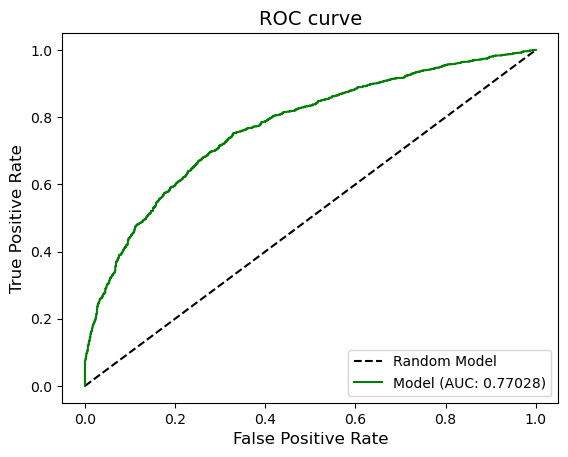

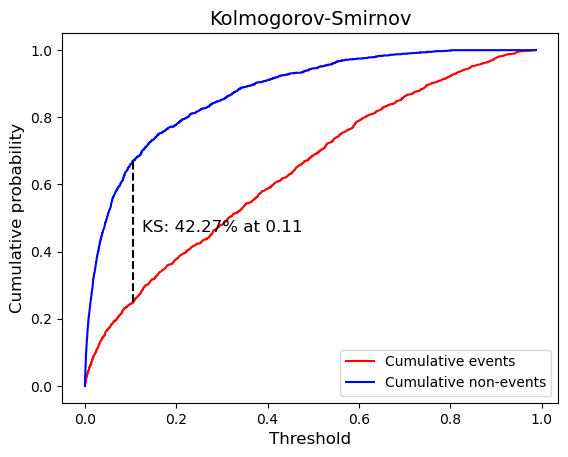

In [115]:
#Training Data
y_pred_train = scorecard.predict_proba(X_train)[:, 1]

plot_auc_roc(y_train, y_pred_train)
plt.show()

plot_ks(y_train, y_pred_train)
plt.show()

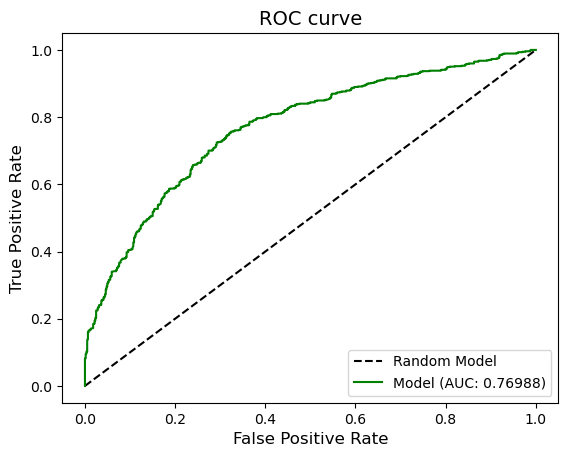

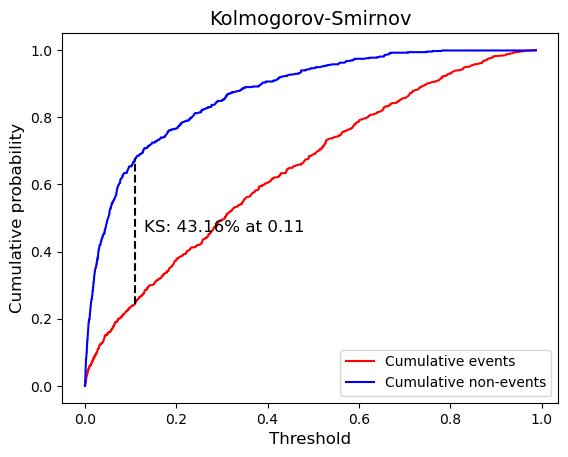

In [116]:
#Test Data
X_test = test[colnames]
y_test = test["GB"]

y_pred_test = scorecard.predict_proba(X_test)[:, 1]

plot_auc_roc(y_test, y_pred_test)
plt.show()

plot_ks(y_test, y_pred_test)
plt.show()

#### Score the Test Data

In [117]:
from sklearn.model_selection import train_test_split

# Recreate split
train_tmp, test_tmp = train_test_split(comb_hard, test_size=0.3, random_state=1234)

test_final = test_tmp.copy()

# Ensure weight exists
if "_freq_" not in test_final.columns:
    test_final["_freq_"] = 1.0

# Score using the fitted optbinning scorecard and the predictor list `colnames`
test_final["score"] = scorecard.score(test_final[colnames])

test_final[["score", "GB"]].head()

,score,GB
2360,620.332443,1
1266,361.100887,0
804,400.307876,0
3798,330.662083,1
3806,391.313243,1


##### Deciles Probability of Default - Test Data

In [118]:
good_weight = final_good_weight

test_final["decile"] = pd.qcut(test_final["score"], 10, labels=False)

# Counts by decile
bad_ct = test_final.loc[test_final["GB"] == 1].groupby("decile").size()
good_ct = test_final.loc[test_final["GB"] == 0].groupby("decile").size()

# Align indices to ensure 0..9 exist
all_dec = pd.Index(range(10), name="decile")
bad_ct = bad_ct.reindex(all_dec, fill_value=0)
good_ct = good_ct.reindex(all_dec, fill_value=0)

PD = bad_ct / (good_ct * good_weight + bad_ct)
PD

decile
0    0.346330
1    0.123730
2    0.087055
3    0.070376
4    0.047675
5    0.038912
6    0.017513
7    0.016957
8    0.009850
9    0.011546
dtype: float64

#### Plot Default across Deciles

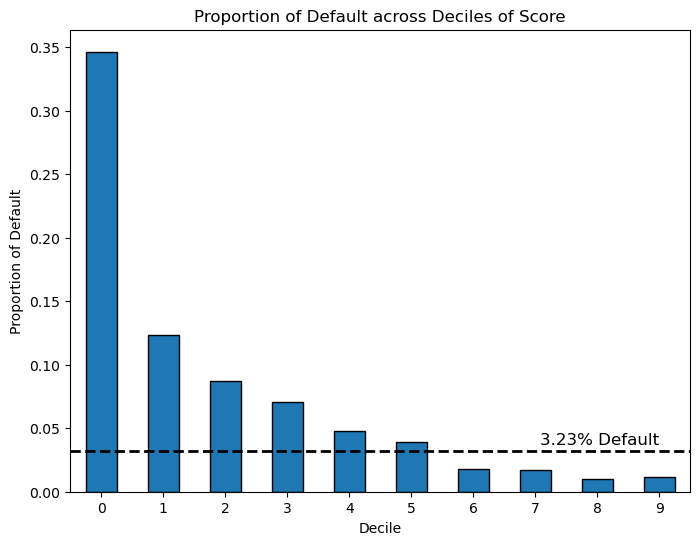

In [119]:
plt.figure(figsize=(8, 6))
PD.plot(kind="bar", edgecolor="black")
plt.axhline(y=0.0323, color="black", linestyle="--", linewidth=2)
plt.text(x=9, y=0.035, s="3.23% Default", color="black", ha="right", va="bottom", fontsize=12)

plt.title("Proportion of Default across Deciles of Score")
plt.xlabel("Decile")
plt.ylabel("Proportion of Default")
plt.xticks(rotation=0)
plt.show()

#### Plot Default Rate vs Acceptance Rate

##### Helper Function

In [120]:
def plot_default_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "GB",
    weight_col: str | None = None,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Default Rate by Acceptance Across Score",
):
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin using in-frame weights (avoids index alignment bugs)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "bad_wt": float((g[bad_col] * g[weight_col]).sum())
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_bad_wt"] = grp["bad_wt"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt
    grp["default_rate_pct"] = 100.0 * grp["cum_bad_wt"] / grp["cum_wt"]

    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["default_rate_pct"] = grp["default_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(grp["_score_mid"], grp["default_rate_pct"], color='red', label="Default Rate (%)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Default Rate (%)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()
    return grp

##### Plot Code

C:\Users\steve\AppData\Local\Temp\ipykernel_24064\4021581396.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


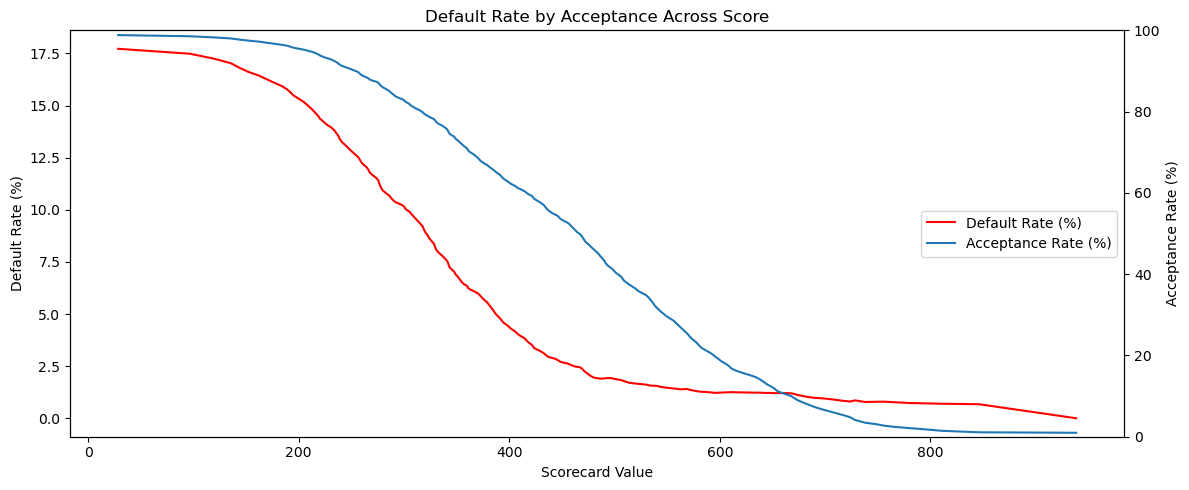

,_score_mid,wt,bad_wt,cum_wt,cum_bad_wt,accept_rate_pct,default_rate_pct
0,938.4525,179.777090,0.0,179.777090,0.0,0.972275,0.000000
1,846.2735,43.282766,3.0,223.059856,3.0,1.089316,0.672465
2,810.9580,179.777090,0.0,402.836945,3.0,1.452422,0.696550
3,795.8640,120.851393,1.0,523.688338,4.0,1.797372,0.713365
4,780.0615,101.208462,1.0,624.896801,5.0,2.113814,0.730719


In [121]:
curve = plot_default_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col="GB",
    weight_col="_freq_" if "_freq_" in test_final.columns else None,
    n_bins=250,
    smooth_window=9,
    title="Default Rate by Acceptance Across Score"
)

curve.head()

#### Profit vs Acceptance Rate

##### Helper Code

In [122]:
def plot_profit_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "bad",
    weight_col: str | None = None,
    profit_if_good: float = 2000.0,
    loss_if_bad: float = 52000.0,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Profit by Acceptance Across Score",
):
    """
    Plot cumulative expected Profit ($) vs Acceptance Rate (%) across score cutoffs.

    For each cutoff score c:
      accepted = rows with score >= c
      acceptance rate = accepted / total
      profit($) = sum_over_accepted( weight * (profit_if_good*(1-bad) - loss_if_bad*bad) )
    """
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Per-row profit contribution
    d["_profit"] = d[weight_col] * (profit_if_good * (1 - d[bad_col]) - loss_if_bad * d[bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin (index-safe)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "profit": float(g["_profit"].sum()),
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_profit"] = grp["profit"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt

    # Optional smoothing (rolling mean)
    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["cum_profit"] = grp["cum_profit"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    # Plot with two y-axes
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(grp["_score_mid"], grp["cum_profit"], color='green', label="Profit ($)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Profit (Tens of Millions $)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    # Combined legend on the right
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()

    return grp

##### Plot Code

C:\Users\steve\AppData\Local\Temp\ipykernel_24064\3144173998.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


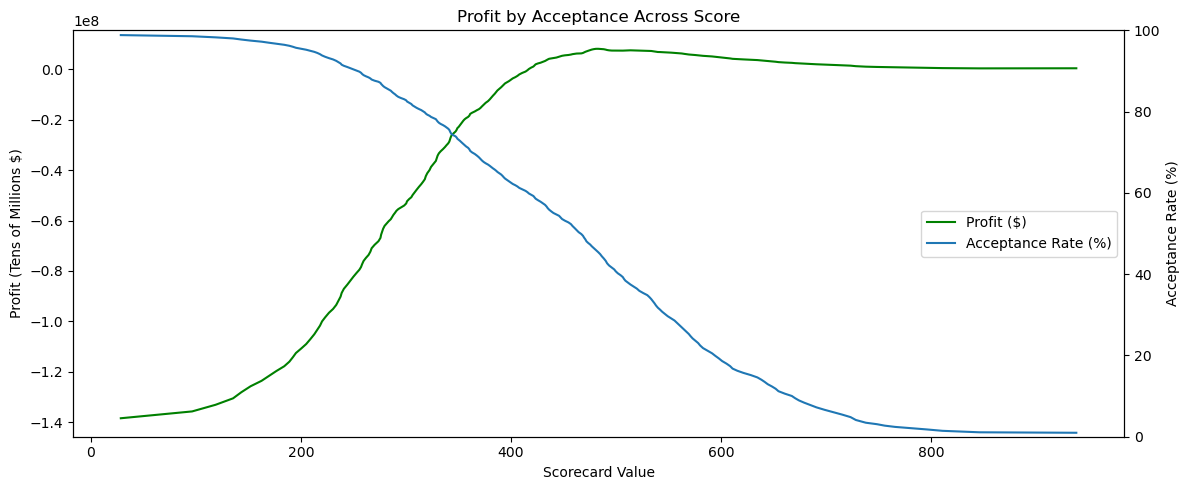

,_score_mid,wt,profit,cum_wt,cum_profit,accept_rate_pct
0,938.4525,179.777090,359554.179567,179.777090,359554.179567,0.972275
1,846.2735,43.282766,-75434.468524,223.059856,321836.945304,1.089316
2,810.9580,179.777090,359554.179567,402.836945,429115.927073,1.452422
3,795.8640,120.851393,187702.786378,523.688338,529681.114551,1.797372
4,780.0615,101.208462,148416.924665,624.896801,619703.611971,2.113814


In [123]:
# Adjust these economics to match your business case:
profit_if_good = 2000.0   # profit on a good loan
loss_if_bad    = 52000.0  # loss on a bad loan (positive number)

profit_curve = plot_profit_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col="GB",
    weight_col="_freq_" if "_freq_" in test_final.columns else None,
    profit_if_good=profit_if_good,
    loss_if_bad=loss_if_bad,
    n_bins=250,
    smooth_window=9,
    title="Profit by Acceptance Across Score"
)

profit_curve.head()

#### Determining Cutoffs

In [ ]:
best = profit_curve.loc[profit_curve["cum_profit"].idxmax()]

best_score = best["_score_mid"]
best_accept = best["accept_rate_pct"]
best_profit = best["cum_profit"]

print(best_score, best_accept, best_profit)

#Risk at Best Profit Score
risk_row = curve.iloc[(curve["_score_mid"] - best_score).abs().idxmin()]

risk_row[["default_rate_pct", "accept_rate_pct"]]

483.1965 45.411393593334296 8078596.032565066


default_rate_pct     1.921370
accept_rate_pct     45.411394
Name: 84, dtype: float64

In [ ]:
#Keeping 75% acceptance rate
target_accept = 75

#Row info for 75% acceptance
row_75 = curve.iloc[(curve["accept_rate_pct"] - target_accept).abs().idxmin()]
print(row_75[["_score_mid", "accept_rate_pct", "default_rate_pct"]])

#best score for 75% acceptance
score_75 = round(row_75['_score_mid'])

#profit for 75% acceptance
profit_75 = profit_curve.iloc[(profit_curve["_score_mid"] - score_75).abs().idxmin()]

print(profit_75[['cum_profit']])

_score_mid          342.006500
accept_rate_pct      75.138319
default_rate_pct      7.424501
Name: 166, dtype: float64
cum_profit   -2.793740e+07
Name: 166, dtype: float64


In [ ]:
#Keeping default rate at 3.23%
target_default = 3.23

row_pd = curve.iloc[(curve["default_rate_pct"] - target_default).abs().idxmin()]
print(row_pd[["_score_mid", "accept_rate_pct", "default_rate_pct"]])

#score for 3.23% default rate
score_pd = row_pd['_score_mid']

#profit for 3.23% default rate
profit_pd = profit_curve.iloc[(profit_curve["_score_mid"] - score_pd).abs().idxmin()]
print(profit_pd[['cum_profit']])

_score_mid          428.302000
accept_rate_pct      57.827685
default_rate_pct      3.256213
Name: 113, dtype: float64
cum_profit    2.565808e+06
Name: 113, dtype: float64
